# **Amazon FC Frontline Attrition Diagnostic & Pilot Intervention**

---



Amazon's 150% annual turnover rate among frontline warehouse workers presents a critical operational challenge, impacting productivity, costs, and long-term workforce stability.

This project analyzes employee-generated feedback to identify 3 key drivers of attrition through sentiment and root cause analyses.

By leveraging unstructured text data, the goal is to translate employee sentiment into actionable business insights and inform a targeted intervention pilot.

This notebook is organized into three primary sections:

1. **Analytical Discovery**  
   Data cleaning, sentiment analysis, cross-platform comparison, and thematic analysis of employee feedback.

2. **Operational Diagnosis**  
   Root cause analysis, workforce prioritization, and problem definition.

3. **Solution Design**  
   Pilot recommendation, implementation scope, and success metrics.

> Note: Sections can be collapsed or expanded **on Google Colab** using the left-side dropdown arrows in the notebook outline for easier navigation.

## Why Employee Feedback Matters

Traditional operational metrics often fail in capturing the lived experiences of frontline workers. Structured data such as metrics do not fully reflect the day-to-day challenges that employee-generated content (such as reviews and public discussions) can provide.

#**Section 1: Analytical Discovery**

---



##**1. Data Sources**
With the goal of capturing a more comprehensive view of employee sentiment, this project's analysis combines data from multiple sources:

- **Glassdoor**: 139 employee reviews structured into pros, cons, summary, and advice to management. Written with Amazon and other employees as the intended audience. This data offers direct and more reflective insights into the workplace experience.
- **YouTube**: 8 day-in-my-life and venting sit down employee videos broken up into 139 transcript snippets. Informal, discussion-based content that reflects unfiltered employee perspectives. Comparatively is unstructured and made for a wider audience as intended viewers.

Combining these sources allow for a more balanced and robust understanding of employee sentiment as it paints a picture of both formal and informal expressions of workplace issues. In total, 278 data records will be analyzed in this section.

## **2. Data Cleaning**


To ensure consistency across platforms, datasets were cleaned and standardized before being combined.

> Notes:
> - Initial inspection included assessing missing values, column relevance, and data consistency to inform cleaning decisions.
> - Field-level Observations: While the primary analysis for glassdoor combines all fields, individual fields such as "pros" and "cons" were also explored separately to validate consistency in themes.

In [1]:
import pandas as pd

glassdoor_df = pd.read_csv('/content/drive/MyDrive/Amazon Attrition Portfolio Project/glassdoor_reviews.csv')
youtube_df = pd.read_csv('/content/drive/MyDrive/Amazon Attrition Portfolio Project/youtube_reviews.csv')

In [2]:
glassdoor_df = (
    glassdoor_df
    .drop(columns=[
        'company_name', 'review_id', 'review_advice',
        'count_unhelpful', 'flag_featured', 'flag_covid',
        'career_opportunities_rating'
    ], errors='ignore')
    .dropna(subset=['summary'])
    .drop_duplicates()
)
youtube_df = youtube_df.dropna(subset=['transcript'])

In [3]:
text_columns = ['review_pros', 'review_cons', 'summary', 'advice_to_management']

glassdoor_df['text'] = glassdoor_df[text_columns].fillna('').agg(' '.join, axis=1)
youtube_df = youtube_df.rename(columns={'transcript': 'text'})

In [4]:
glassdoor_df['platform'] = 'Glassdoor'
youtube_df['platform'] = 'YouTube'

combined_df = pd.concat([glassdoor_df, youtube_df], ignore_index=True)

In [5]:
combined_df.to_csv('combined_sentiment.csv', index=False)

## **3. Text Preprocessing**

The raw text data was prepared for analysis by normalizing (standardizing casing and removing punctuation), tokenizing, and removing stop words.



In [6]:
import nltk
import string
from nltk.corpus import stopwords
nltk.download('stopwords')

def clean_text(text):
    if pd.isnull(text):
        return ""
    tokens = text.lower().translate(str.maketrans('', '', string.punctuation)).split()
    return ' '.join([word for word in tokens if word not in stopwords.words('english')])

combined_df['cleaned_text'] = combined_df['text'].apply(clean_text)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


## **4. Exploratory Text Analysis**

Initial keyword analysis highlights frequently mentioned workplace themes. The focus in this step lies in a cursory view for terms and phrases that potentially indicates underlying operational challenges.

In [7]:
from collections import Counter

# Combine all text into a single word list
all_words = ' '.join(
    combined_df['cleaned_text'].fillna('').astype(str)
).split()

In [8]:
word_counts = Counter(all_words)
word_counts.most_common(10)

[('work', 141),
 ('like', 116),
 ('good', 89),
 ('pay', 80),
 ('get', 75),
 ('time', 52),
 ('job', 51),
 ('benefits', 50),
 ('amazon', 49),
 ('day', 45)]

In [9]:
stop_keywords = [
    # Common filler words (basic cleanup)
    'and','to','the','for','are','with','of','you','on','a',
    'in','or','not','they','more','your',

    # Platform/company noise
    'amazon','company','work','employee','employees', 'job', 'warehouse',
    'associates','associate','people','fulfillment','center',

    # Conversational/spoken language (YouTube)
    'like','get','going','go','dont','im','youre', 'yall',
    'really','thats','know','want','day', 'sure'
]

filtered_words = [w for w in all_words if w not in stop_keywords]
filtered_counts = Counter(filtered_words)

In [10]:
filtered_counts.most_common(10)

[('good', 89),
 ('pay', 80),
 ('time', 52),
 ('benefits', 50),
 ('hours', 39),
 ('shift', 36),
 ('working', 35),
 ('long', 30),
 ('great', 30),
 ('break', 28)]

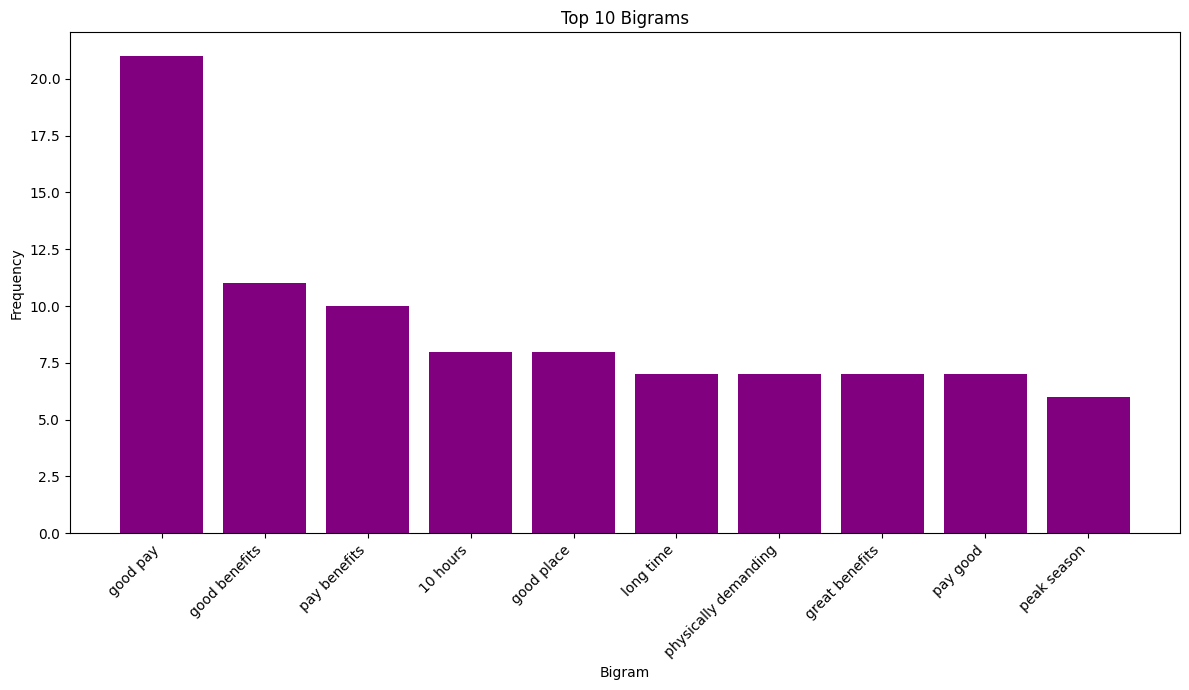

In [11]:
import matplotlib.pyplot as plt
import nltk
from collections import Counter

filtered_bigrams = list(nltk.bigrams(filtered_words))

filtered_bigram_counts = Counter(filtered_bigrams)

common_filtered_bigrams = filtered_bigram_counts.most_common(10)

filtered_bg_labels = [' '.join(bg) for bg, count in common_filtered_bigrams]
filtered_bg_counts = [count for bg, count in common_filtered_bigrams]

plt.figure(figsize=(12, 7))
plt.bar(filtered_bg_labels, filtered_bg_counts, color='purple')
plt.title("Top 10 Bigrams")
plt.xlabel("Bigram")
plt.ylabel("Frequency")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

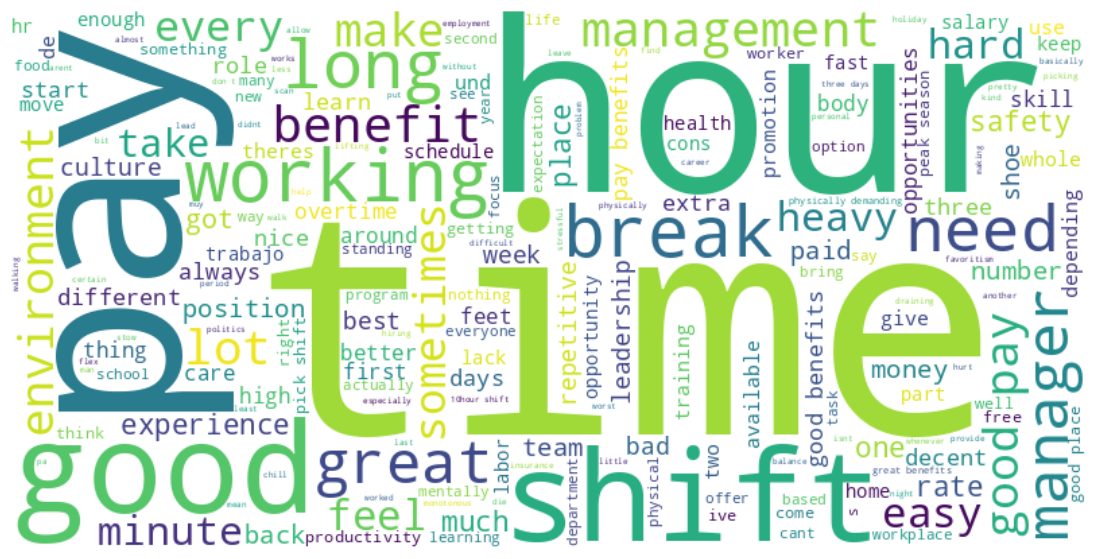

In [12]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

wordcloud = WordCloud(width=800, height=400, background_color='white')\
    .generate(' '.join(filtered_words))

plt.figure(figsize=(15, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

Initial phrase frequency analysis suggests recurring themes related to **scheduling demands** ("10 hours", "peak season") and **burnout-related strain** ("physically demanding"), with additional discussion surrounding **workplace management** experiences.

Pay is also a top theme based on this cursory analysis, however from the bigram generated it is only paired with positive words so it will not be a focused theme in the analysis going forward. Instead, management experiences will be looked into as a secondary theme.

In [13]:
# Cross-platform comparison
glassdoor_words = ' '.join(
    combined_df[combined_df['platform'] == 'Glassdoor']['cleaned_text']
).split()

youtube_words = ' '.join(
    combined_df[combined_df['platform'] == 'YouTube']['cleaned_text']
).split()

glassdoor_filtered = [w for w in glassdoor_words if w not in stop_keywords]
youtube_filtered = [w for w in youtube_words if w not in stop_keywords]

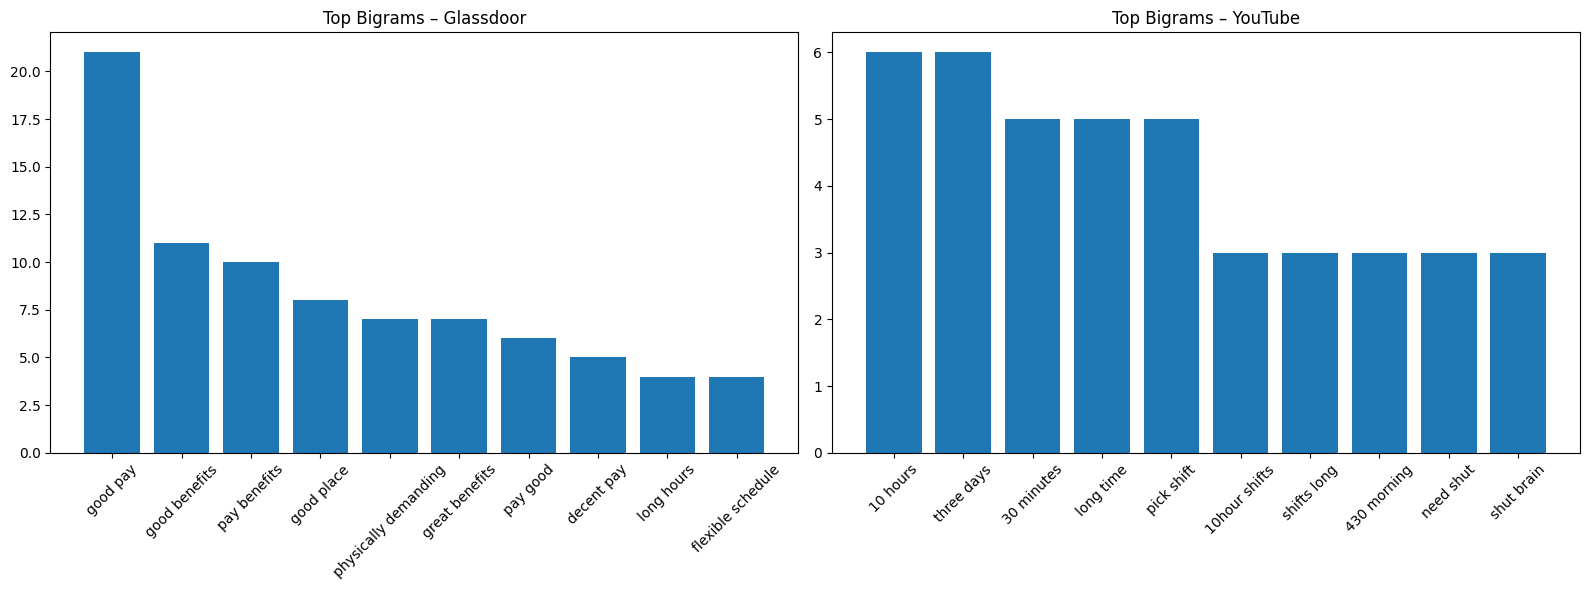

In [14]:
import matplotlib.pyplot as plt
from collections import Counter
from nltk.util import ngrams

glassdoor_bigrams = Counter(list(ngrams(glassdoor_filtered, 2)))
youtube_bigrams = Counter(list(ngrams(youtube_filtered, 2)))

g_top = glassdoor_bigrams.most_common(10)
y_top = youtube_bigrams.most_common(10)

g_labels = [' '.join(bg) for bg, _ in g_top]
g_counts = [count for _, count in g_top]

y_labels = [' '.join(bg) for bg, _ in y_top]
y_counts = [count for _, count in y_top]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].bar(g_labels, g_counts)
axes[0].set_title("Top Bigrams – Glassdoor")
axes[0].tick_params(axis='x', rotation=45)

axes[1].bar(y_labels, y_counts)
axes[1].set_title("Top Bigrams – YouTube")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

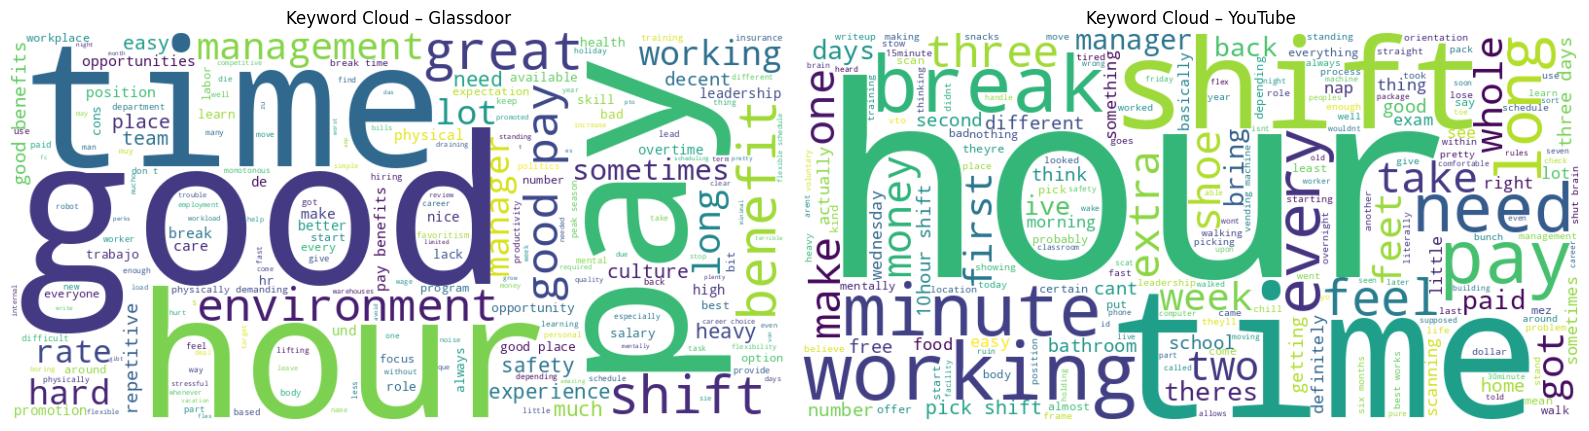

In [15]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

glassdoor_wc = WordCloud(width=800, height=400, background_color='white')\
    .generate(' '.join(glassdoor_filtered))

youtube_wc = WordCloud(width=800, height=400, background_color='white')\
    .generate(' '.join(youtube_filtered))

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

axes[0].imshow(glassdoor_wc, interpolation='bilinear')
axes[0].set_title("Keyword Cloud – Glassdoor")
axes[0].axis('off')

axes[1].imshow(youtube_wc, interpolation='bilinear')
axes[1].set_title("Keyword Cloud – YouTube")
axes[1].axis('off')

plt.tight_layout()
plt.show()

When examined by platform, the bigram and keyword distributions reveal distinct communication patterns that reflect each platform's audience and purpose.


*   In Glassdoor reviews, employees are seen consciously weighing pros and cons when writing, aligning with the structured, assessment-oriented tone that is consistent with Glassdoor's design as a company-directed feedback-channel. Notably, despite the overall positive framing, operational strain still surfaces.
*   YouTube comments display a sharply different linguistic profile, as top bigrams are concrete and time-obsessed reflecting lived, granular experiences. It is evident that employees are narrating their experience to the audience as decompression language like "need shut" and "shut brain" appear in the top bigrams, suggesting that YouTube functions as a peer processing space rather than a formal reporting channel.

Across both platforms, time and physical demand emerge as the connective thread. Glassdoor encodes it evaluatively, while YouTube encodes it experientially. This convergence across two structurally different platforms strengthens the case that scheduling strain and burnout are not platform-specific complaints but instead are consistent operational realities.

## **5. Overall Sentiment Analysis**

To further progress analysis depth beyond surface-level themes, sentiment analysis is utilized to quantify how frontline employees feel about their work environment.

Each review was scored based on **sentiment polarity (positive, neutral, negative) and subjectivity (opinion-based vs factual).** This enables identification of emotional patterns within feedback and will allow for a measurable foundation for identifying dissatisfaction patterns.

In [16]:
from textblob import TextBlob
import pandas as pd

combined_df['sentiment_polarity'] = combined_df['cleaned_text'].apply(lambda x: TextBlob(x).sentiment.polarity)
combined_df['sentiment_subjectivity'] = combined_df['cleaned_text'].apply(lambda x: TextBlob(x).sentiment.subjectivity)

def label_sentiment(score):
    if score > 0.1:
        return 'positive'
    elif score < -0.1:
        return 'negative'
    else:
        return 'neutral'

combined_df['sentiment_label'] = combined_df['sentiment_polarity'].apply(label_sentiment)

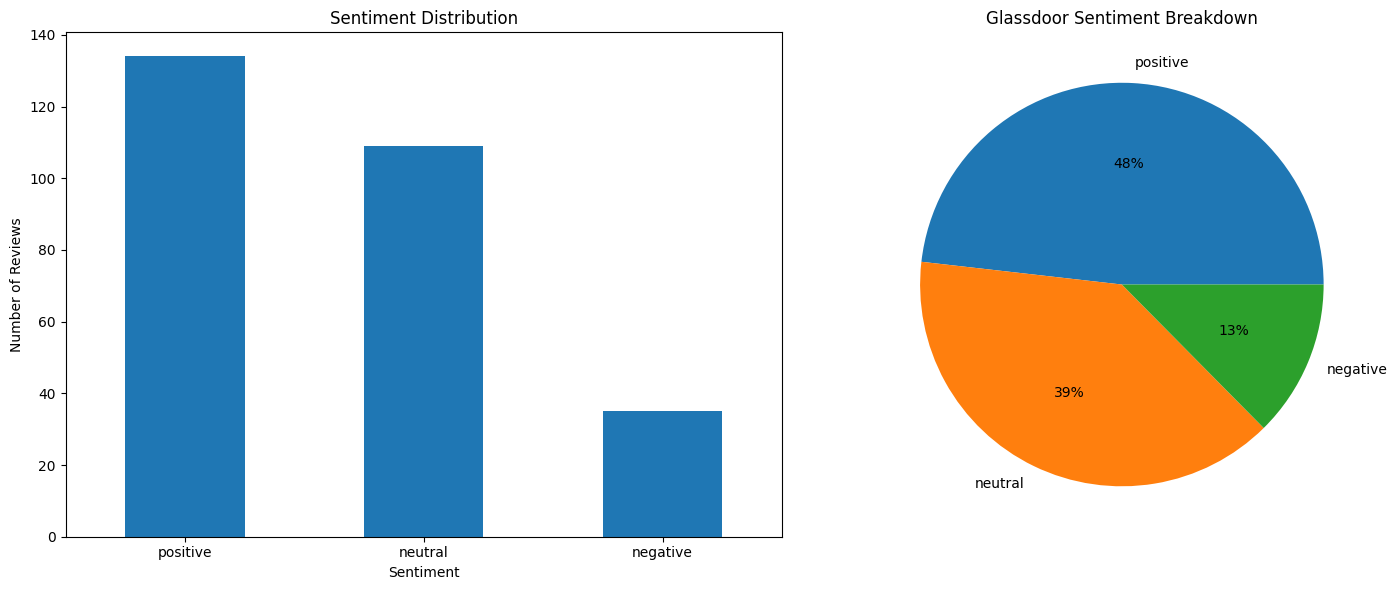

In [17]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

combined_df['sentiment_label'].value_counts().plot(
    kind='bar',
    title="Sentiment Distribution",
    ax=axes[0]
)
axes[0].set_xlabel("Sentiment")
axes[0].set_ylabel("Number of Reviews")
axes[0].tick_params(axis='x', rotation=0)

combined_df['sentiment_label'].value_counts().plot(
    kind='pie',
    autopct='%1.0f%%',
    title="Glassdoor Sentiment Breakdown",
    ax=axes[1],
    ylabel=''
)

plt.tight_layout()
plt.show()

While sentiment analysis provides a structured overview of employee perceptions, rule-based NLP tools such as TextBlob have limitations when interpreting context-specific workplace language. Certain phrases associated with operational strain (e.g. “demanding”, “long hours”, or “physically exhausting”) may still receive neutral or positive sentiment classifications depending on surrounding language. Consequently, the following outputs attempts to address this limitation by applying an **additional keyword-based strain signal detection** containing indicators of schedule pressure, burnout-related experiences, or management issues.

In [18]:
import re

negative_patterns = [
    r'overwork\w*',
    r'exhaust\w*',
    r'burnout',
    r'stress\w*',
    r'tired\w*',
    r'pressure\w*',
    r'long\s+hour\w*',
    r'long\s+shift\w*',
    r'no\s+break\w*',
    r'short\s+break\w*',
    r'unpredict\w*',
    r'understaff\w*',
    r'no\s+support',
    r'poor\s+management',
    r'frustrat\w*',
    r'difficult\w*',
    r'hard\s+work',
    r'demand\w*',
    r'drain\w*',
    r'physic\w*',
    r'mental\w*',
    r'unfair\w*',
    r'favorit\w*',
    r'nepotis\w*',
    r'crony\w*',
    r'bias\w*',
    r'politic\w*',
    r'clique\w*',
    r'double\s+standard\w*',
    r'rigged',
    r'lack\s+of\s+merit',
    r'who\s+you\s+know',
    r'not\s+what\s+you\s+know'
]

In [19]:
def contains_negative_signal(text, patterns):
    for pattern in patterns:
        if re.search(pattern, text, re.IGNORECASE):
            return True
    return False

combined_df['strain_signal_flag'] = combined_df['cleaned_text'].apply(
    lambda x: contains_negative_signal(x, negative_patterns)
)

# Reviews labeled as neutral OR positive
potentially_misclassified = combined_df[
    combined_df['sentiment_label'].isin(['neutral', 'positive'])
]

# Total count
potentially_misclassified_count = potentially_misclassified.shape[0]

# Reviews containing hidden strain signals
strain_signal_flag = potentially_misclassified[
    potentially_misclassified['strain_signal_flag'] == True
].shape[0]

strain_signal_flag, potentially_misclassified_count

(58, 243)

In [20]:
percentage = (strain_signal_flag / potentially_misclassified_count) * 100
percentage

23.868312757201647

Approximately 24% of reviews classified as neutral or positive contain language associated with workplace strain.

This observation shows that sentiment analysis may under-detect dissatisfaction when employees describe both positive and negative experiences within the same review or when more moderated or indirect phrasing is used.

As a result, further analysis will consider neutral and positive sentiment as a potential mix of positive and negative experiences, rather than safely concluding a complete absence of issues.

## **6. Cross-Platform Sentiment Comparison**

Sentiment patterns were compared across Glassdoor and YouTube to examine how workplace experiences are expressed in different communication contexts.

Analysis was conducted through 3 lens: tone, depth & structure, and platform/audience context. By comparing these platforms, additional context into how workplace strain and emotional intensity are communicated can be unraveled.

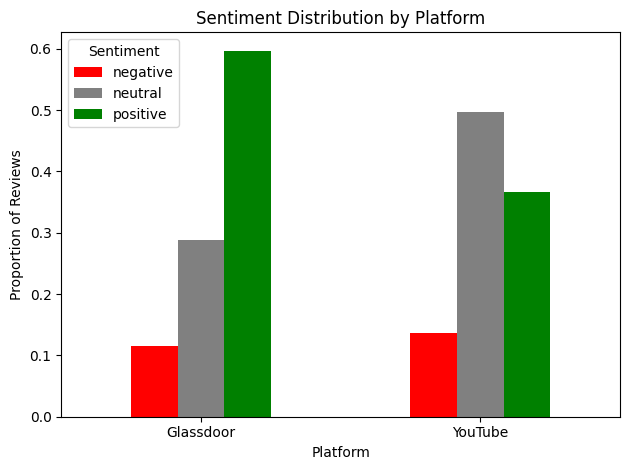

In [21]:
sentiment_by_platform = (
    combined_df
    .groupby(['platform', 'sentiment_label'])
    .size()
    .unstack()
    .apply(lambda x: x / x.sum(), axis=1)
)

sentiment_by_platform.plot(kind='bar', color={'negative': 'red', 'neutral': 'gray', 'positive': 'green'})

plt.title("Sentiment Distribution by Platform")
plt.xlabel("Platform")
plt.ylabel("Proportion of Reviews")
plt.xticks(rotation=0)
plt.legend(title="Sentiment")
plt.tight_layout()
plt.show()

Glassdoor reviews show a higher proportion of positive sentiment overall, while YouTube discussions contain comparatively higher neutral and negative sentiment proportions. This suggests that employees may communicate workplace concerns differently depending on platform context, with structured review platforms encouraging more moderated feedback and informal platforms enabling more direct or emotionally expressive discussion.

The combination of the previous decompression language appearing in YouTube bigrams and its comparatively higher neutral and negative sentiment proportions points to a behavioural pattern that is worth noting. Employees appear to be processing workplace frustration externally and in a peer-directed way rather than through internal channels. It can be then inferred that with the primary outlet for dissatisfaction being a public platform aimed at other/propective workers rather than the employer, **internal feedback mechanisms may be systematically undercounting the true scale of operational strain**.

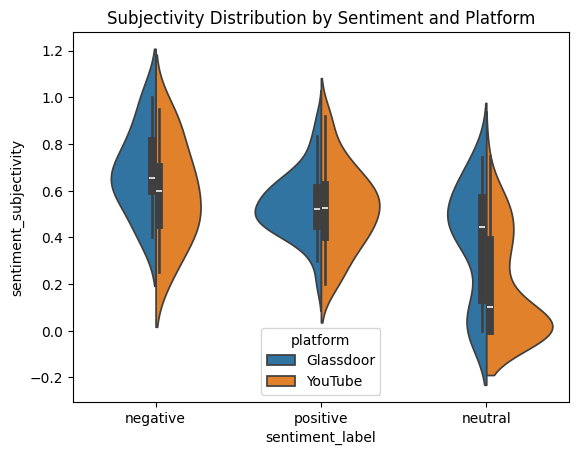

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.violinplot(
    data=combined_df,
    x='sentiment_label',
    y='sentiment_subjectivity',
    hue='platform',
    split=True
)

plt.title("Subjectivity Distribution by Sentiment and Platform")
plt.show()

**Negative sentiment across both platforms is associated with higher subjectivity, indicating that dissatisfaction is often expressed with stronger emotional intensity.** However, Glassdoor's negative sentiment shows denser mass in the upper subjectvity range which suggests that when employees write negative reviews they do so with consistently high emotional weight. Comparatively, YouTube's negative sentiment is more wide spread, meanwhile its neutral sentiment shows wider variation extending toward zero subjectivity. This reflects a more mixed and conversational nature of YouTube commentary where neutral responses range from completely factual to moderately expressive.

In [23]:
hidden_negative_by_platform = (
    combined_df[combined_df['sentiment_label'] == 'neutral']
    .groupby('platform')['strain_signal_flag']
    .mean()
)

hidden_negative_by_platform

,strain_signal_flag
platform,
Glassdoor,0.525000
YouTube,0.072464


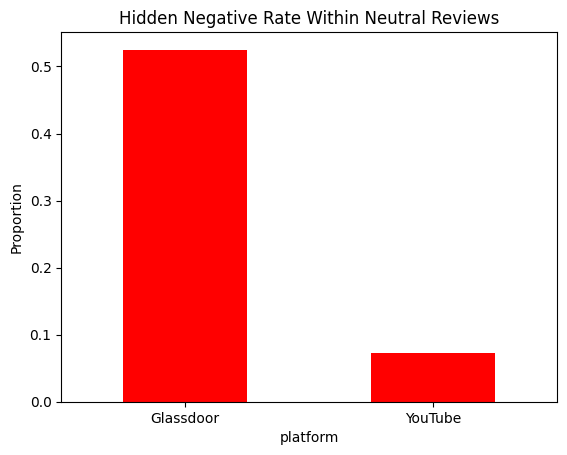

In [24]:
hidden_negative_by_platform.plot(kind='bar', color='red')

plt.title("Hidden Negative Rate Within Neutral Reviews")
plt.ylabel("Proportion")
plt.xticks(rotation=0)
plt.show()

Glassdoor reviews contain a substantially higher proportion of hidden strain signals within neutral and positive sentiment classifications compared to YouTube. This suggests that structured workplace reviews may encourage more moderated or balanced language, causing operational concerns to appear less overtly negative despite containing indicators of scheduling pressure or burnout-related experiences.

Overall, **cross-platform comparison suggests that workplace dissatisfaction is not expressed uniformly across communication channels**. While YouTube captures more overt emotional expression, Glassdoor reviews more frequently embed operational concerns within otherwise neutral or balanced feedback. As a result, analyzing multiple feedback sources provides a more complete understanding of frontline employee experiences and dissatisfaction patterns.

## **7. Thematic Analysis**

Thematic analysis was applied to identify what frontline employees are actually dissatisfied about, not just that dissatisfaction exists. Keyword-based tagging across the combined dataset surfaced three operational themes: burnout, scheduling pressure, and management experience.

Previously, the limitations of rule-based sentiment analysis have been taken into account. This consideration is further applied throughout this section as reviews containing hidden operational strain signals were incorporated into adjusted dissatisfaction-related analysis. This ensures that understated dissatisfaction is captured in the thematic comparison.

In [25]:
risk_reviews = combined_df[
    (combined_df['sentiment_label'] == 'negative') |
    (combined_df['strain_signal_flag'] == True)
].copy()

In [26]:
import pandas as pd

theme_keywords = {

    'Burnout': [
        'burnout', 'exhaust', 'fatigue',
        'stress', 'stressful', 'draining',
        'tired', 'physically', 'mentally',
        'demanding', 'overwork', 'overworked',
        'long hours', 'no break',
        'sore', 'injury', 'sleep',
        'recovery'
    ],

    'Scheduling Pressure': [
        'shift', 'schedule', 'hours',
        'night shift', 'weekend',
        'mandatory overtime',
        'overtime', 'time off'
    ],

    'Management Bias': [
        'management', 'manager',
        'supervisor', 'leadership',
        'favoritism', 'unfair',
        'bias', 'politics',
        'double standards',
        'support'
    ]
}

In [27]:
def tag_themes(text, theme_keywords):
    matched = []

    for theme, keywords in theme_keywords.items():
        if any(keyword in str(text).lower() for keyword in keywords):
            matched.append(theme)

    return ', '.join(matched) if matched else ''

In [28]:
risk_reviews['themes'] = risk_reviews['cleaned_text'].apply(
    lambda x: tag_themes(x, theme_keywords)
)

In [29]:
theme_counts = (
    risk_reviews['themes']
    .str.get_dummies(sep=', ')
    .sum()
    .sort_values(ascending=False)
)

theme_counts

,0
Burnout,39
Scheduling Pressure,34
Management Bias,26


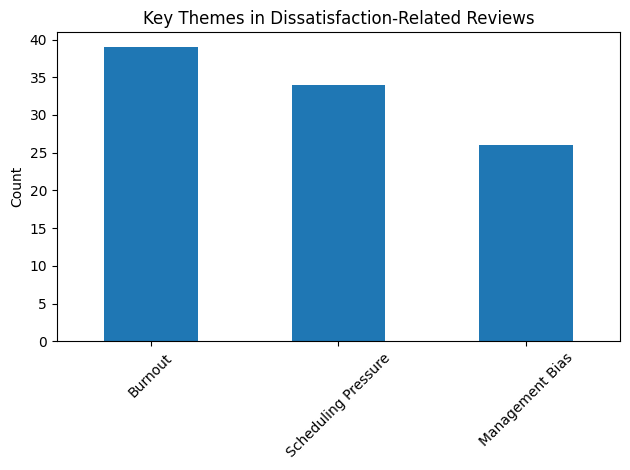

In [30]:
import matplotlib.pyplot as plt

theme_counts.plot(kind='bar')

plt.title("Key Themes in Dissatisfaction-Related Reviews")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

The most prominent dissatisfaction theme is **burnout-related strain, followed by scheduling pressure and management-related concerns**. Combined, these themes suggests that operational workload intensity, recovery limitations, and perceived workplace support challenges are recurring drivers of employee dissatisfaction.

In [31]:
combined_df['themes'] = combined_df['cleaned_text'].apply(
    lambda x: tag_themes(x, theme_keywords)
)

In [32]:
combined_df['adjusted_sentiment'] = combined_df['sentiment_label']

combined_df.loc[
    combined_df['strain_signal_flag'] == True,
    'adjusted_sentiment'
] = 'negative'

In [33]:
theme_dummies = combined_df['themes'].str.get_dummies(sep=', ')

theme_df = pd.concat([combined_df, theme_dummies], axis=1)

In [34]:
theme_sentiment = []

for theme in theme_dummies.columns:

    temp = (
        theme_df[theme_df[theme] == 1]
        .groupby('adjusted_sentiment')
        .size()
        .reset_index(name='count')
    )

    temp['theme'] = theme

    theme_sentiment.append(temp)

theme_sentiment_df = pd.concat(theme_sentiment)

In [35]:
theme_sentiment_df['proportion'] = (
    theme_sentiment_df.groupby('theme')['count']
    .transform(lambda x: x / x.sum())
)

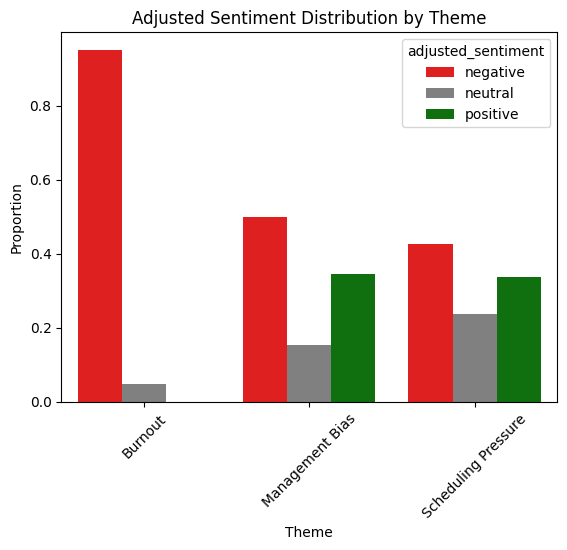

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(
    data=theme_sentiment_df,
    x='theme',
    y='proportion',
    hue='adjusted_sentiment',
    palette={'negative': 'red', 'neutral': 'gray', 'positive': 'green'}
)

plt.title("Adjusted Sentiment Distribution by Theme")

plt.ylabel("Proportion")
plt.xlabel("Theme")

plt.xticks(rotation=45)

plt.show()

### Representative Employee Feedback

The quantitative patterns above are grounded in how employees actually describe these experiences. The excerpts below illustrate the operational specificity behind each theme.

| Theme | Representative Employee Quote | Platform |
|---|---|---|
| Physical & Mental Burnout | "...there's so much pressure to increase performance consistently that lots of people are cutting corners...ended up with a repetitive motion injury in my hand...” | Glassdoor |
| Management Bias | “...they always put me in the hardest thing while others got easier work...” | YouTube |
| Scheduling Pressure | “Forced mandatory extra time...you use part of your break just walking back...” | Glassdoor |

###Scheduling Pressure

Scheduling Pressure shows a relatively balanced three-way distribution, making it the most evenly spread theme in the dataset. The meaningful positive proportion supports the idea that shift flexibility is genuinely valued when it works, functioning as a hidden strength within an otherwise strained operational context. The neutral presence, while moderate, suggests that many employees process scheduling demands as a logistical reality rather than a personal grievence. That is, until mandatory overtime and shift length push them past a tolerance threshold.

###Management Bias

Management Bias shows the most divided sentiment distribution of the three themes, with approximately 50% negative and 35% positive, the highest positive proportion across all themes. This split suggests that experiences with management vary significantly across individuals, with some employees reporting fair treatment while others encounter systemic favoritism. The almost similar weight of negative and positive sentiment makes this theme exceptionally complex. It is not universally damaging but where it is negative, the consequences for trust and retention are disproportionate precisely because the harm feels personal and discretionary rather than structural.

###Physical and Mental Burnout

Burnout shows the most severe and unambiguous sentiment profile at approximately 95% negative with near-zero neutral presence. This neutral level is analytically significant, it indicates that burnout functions as a threshold experience rather than a gradual one. Employees either have not reached it yet or are already past the point of tolerance, with almost no middle ground. This pattern justifies treating burnout as the most urgent theme.

The conclusion of burnout as the main theme is in consideration of not only its severity in isolation but also of how **it represents the convergence point of the other two stressors: scheduling pressure drives the physical toll while management bias removes the psychogical safety net. Burnout is therefore the most critical indicator of systemic failure even when workers do not name it directly.**

This severity hierarchy (Burnout > Management > Scheduling Issues) forms the analytical basis for the pilot recommendation section.

## **8. Key Analytical Insights**



- Physical and mental burnout is the most prevalent dissatisfaction theme across both platforms. Glassdoor surfaces chronic strain indicators like repetitive injury and back problems, while YouTube captures acute emotional responses in real time. This signals that workload toll represents the highest reputational and retention risk in the dataset.
- A significant gap in psychological safety is evident as employees turn to YouTube to vent about their experiences rather than directing feedback internally, suggesting that internal feedback channels are failing to capture primary attrition drivers.
- Standard sentiment analysis undercounted operational strain language; keyword-based reclassification of hidden negative signals revealed burnout severity significantly higher than surface-level scores suggested, particularly within reviews initially labelled neutral.


# **Section 2: Operational Diagnosis**

---



##**8. Root Cause Analysis**

The thematic findings identified physical and mental burnout operational strain as the dominant pattern across dissatisfaction-related reviews. A 5 Whys root cause analysis was conducted to better understand the underlying conditions contributing to burnout and elevated attrition risk.

###**5 Whys Analysis**

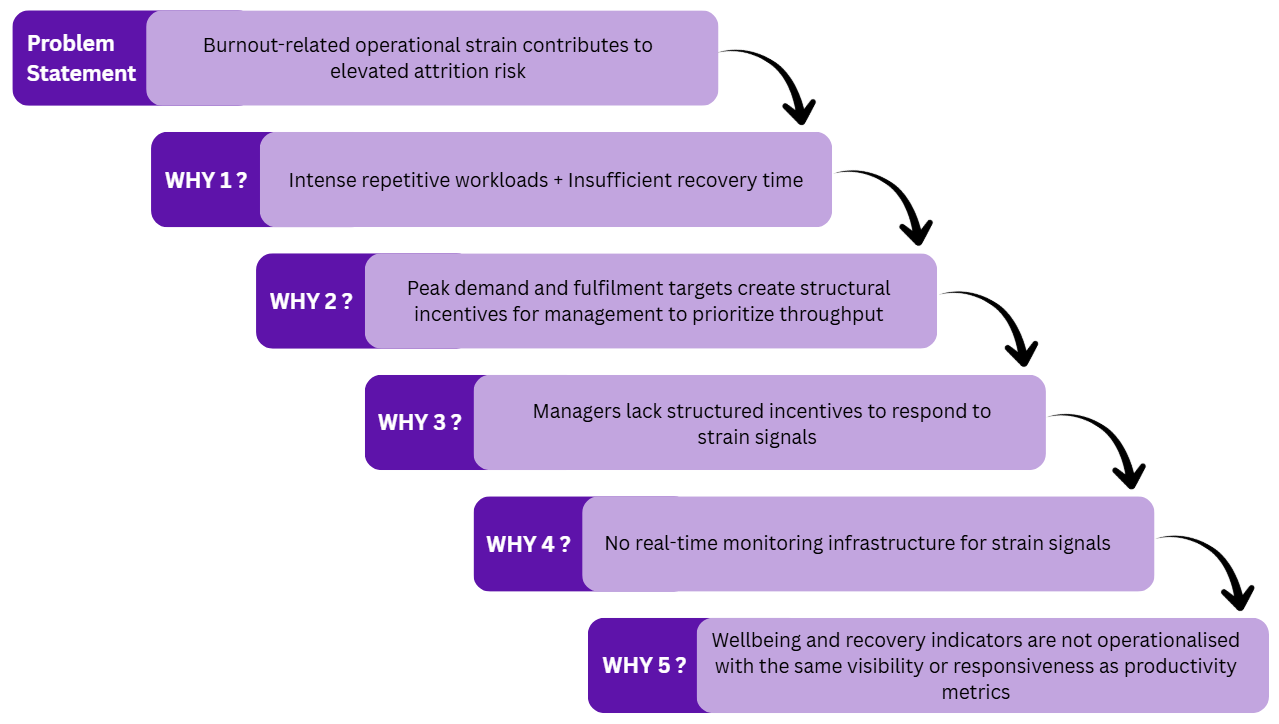

###**Root Cause**
The root cause analysis suggests that burnout-related strain is not solely driven by individual workload intensity but also by how operational systems prioritize measurable productivity outcomes over employee recovery indicators.

While throughput metrics are continuously monitored and operationalized into decision-making, strain-related signals such as fatigue and recovery limitations appear to have significantly lower operational visibility. This creates a metric legibility gap where productivity pressures are systematically reinforced while burnout signals remain difficult to detect and respond to in real time.

##**9. Workforce Segmentation & Prioritization**

With the goal of maximizing actionability of the final pilot recommendation, segmentation analysis was conducted to identify which employee group should be prioritized. Additionally, this aligns with Amazon FC's current realities as operational strain is not experienced uniformly across the warehouse workforce.

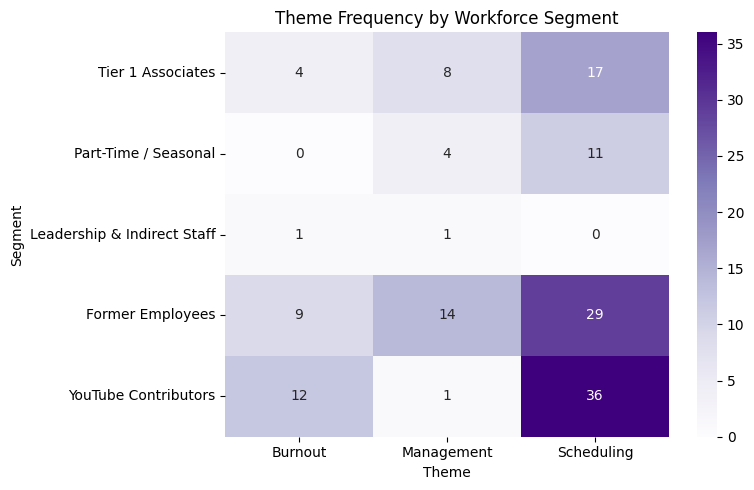

In [37]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

segment_theme_df = pd.DataFrame({
    'Burnout': [4, 0, 1, 9, 12],
    'Management': [8, 4, 1, 14, 1],
    'Scheduling': [17, 11, 0, 29, 36]
},
index=[
    'Tier 1 Associates',
    'Part-Time / Seasonal',
    'Leadership & Indirect Staff',
    'Former Employees',
    'YouTube Contributors'
])

plt.figure(figsize=(8, 5))

sns.heatmap(
    segment_theme_df,
    annot=True,
    cmap='Purples',
    fmt='g'
)

plt.title("Theme Frequency by Workforce Segment")

plt.xlabel("Theme")
plt.ylabel("Segment")

plt.tight_layout()
plt.show()

###**Priority Scoring**

| Segment                     | Impact | Severity | Size | Priority Score | Strategic Rationale                                                                   |
| --------------------------- | -----: | -------: | ---: | -------------: | ------------------------------------------------------------------------------------- |
| Tier 1 Associates           |      5 |        4 |    4 |             80 | Highest operational exposure and burnout severity across a large frontline workforce. |
| Part-Time / Seasonal        |      4 |        3 |    3 |             36 | Acts as a peak-demand labor buffer despite lower overall dissatisfaction severity.    |
| Leadership & Indirect Staff |      5 |        2 |    1 |             10 | Smaller group with high operational influence but limited strain indicators.          |
| Former Employees            |      2 |        5 |    5 |             50 | High dissatisfaction severity with strong reputational and diagnostic insight value.  |
| YouTube Contributors        |      1 |        3 |    3 |              9 | Valuable qualitative signal source but limited intervention targeting precision.      |


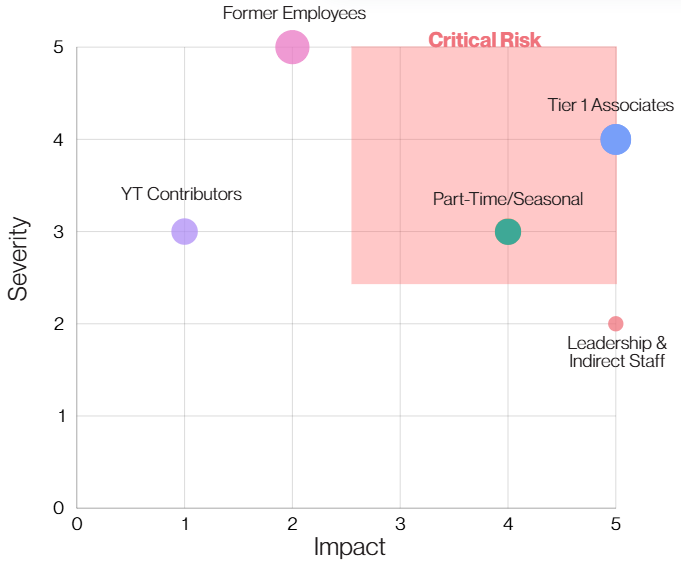

Although Former Employees demonstrated the highest dissatisfaction severity, they were not prioritized as the primary intervention target because the analysis focus was placed on operationally actionable frontline populations. Their feedback provided strong diagnostic and reputational insight value but limited direct intervention feasibility.

Part-Time/Seasonal employees also appeared within the critical risk zone due to scheduling-related strain exposure during peak demand periods. However, **Tier 1 Associates were ultimately prioritized** because they combined high burnout severity, sustained operational exposure, and larger workforce impact within core frontline operations.

###**Tier 1 Associates Friction Map**

| Friction Area                           | Representative Feedback                                                                                                                                                                          |
| --------------------------------------- | ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------ |
| Productivity Pressure & Physical Strain | “There’s so much pressure to increase performance consistently that lots of people are cutting corners just to keep from getting canned… I ended up with a repetitive motion injury in my hand.” |
| Favoritism & Unequal Advancement        | “They show they are giving fair chances to everyone, but it’s not true at ground level… lack of support from HR when you actually need information.”                                             |
| Scheduling Strain                       | “Mandatory overtime with little to no heads up. This place drains you emotionally and physically.”                                                                                               |



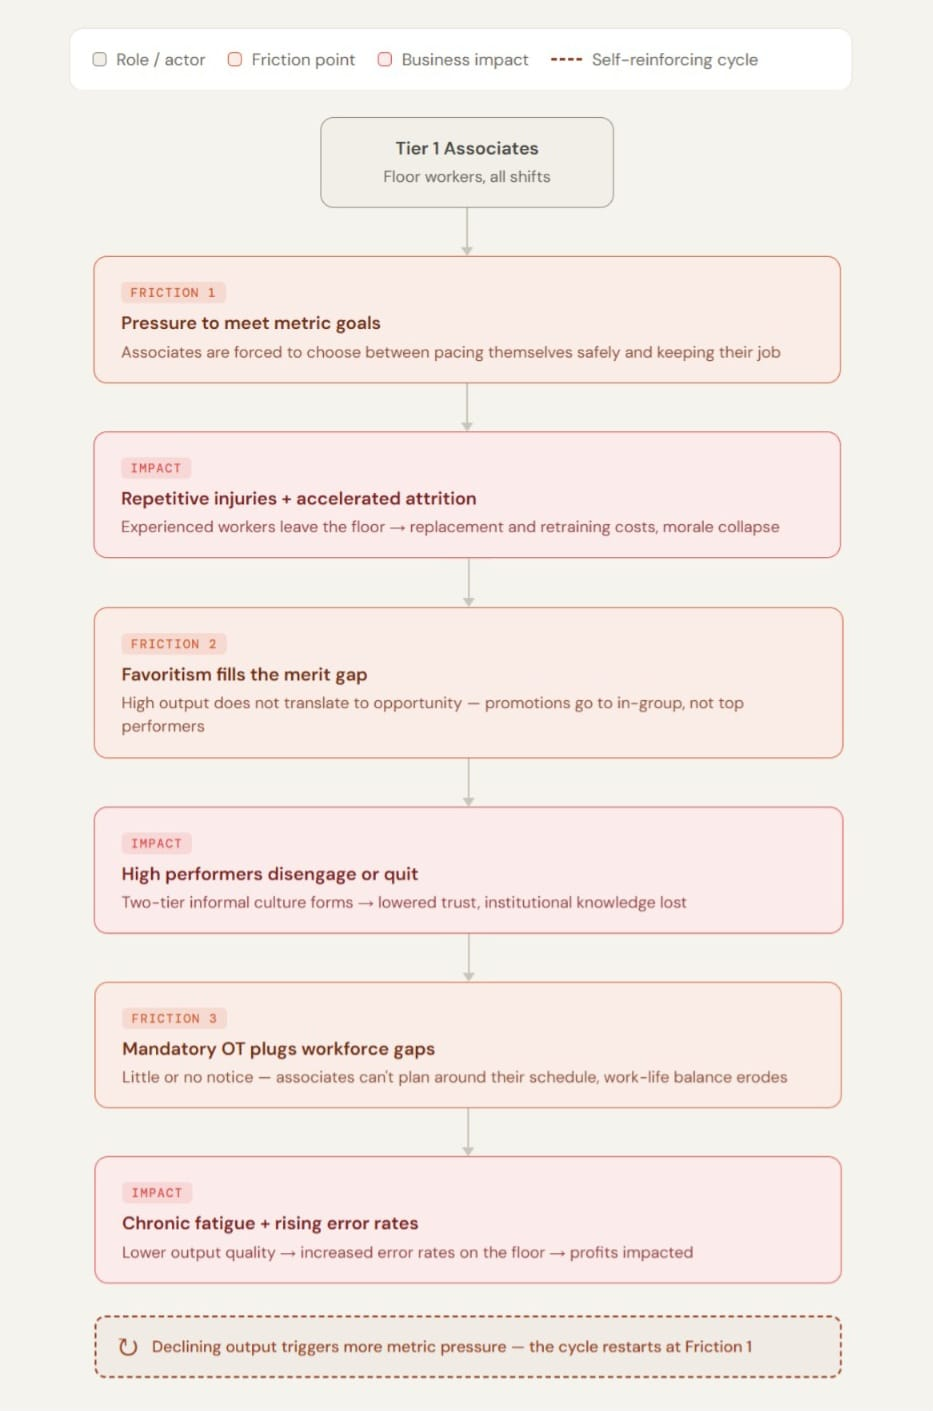

The friction mapping exercise suggests that frontline burnout is reinforced through interconnected operational pressures rather than isolated workplace issues. Productivity expectations, scheduling strain, and perceived inequities in workplace support collectively create conditions where associates experience sustained physical and emotional exhaustion over time.

These pressures not only affect employee wellbeing, but also contribute to broader operational risks including reduced productivity quality, increased turnover, retraining costs, and declining workforce morale.

##**10. Problem Statement**

The operational diagnosis process was synthesized into a focused problem statement to define the primary intervention area for pilot design.

| Component              | Final Focus                                                                  |
| ---------------------- | ---------------------------------------------------------------------------- |
| Primary Theme          | Burnout-Related Operational Strain                                           |
| Priority Segment       | Tier 1 Associates                                                            |
| Core Friction Point    | Sustained productivity pressure with limited recovery visibility             |
| Key Root Cause Insight | Productivity metrics are operationalized more visibly than strain indicators |


### Final Problem Statement

Tier 1 Associates are experiencing sustained burnout-related strain that current operational systems neither detect nor address, which leads to attrition risk and hidden operational costs that compound over time (with turnover and retraining).

# **Section 3: Solution Design**

---



###**Pilot Recommendation**

Based on the operational diagnosis findings, a pilot intervention was designed to address burnout-related strain through standardized workload balancing and improved visibility into frontline fatigue indicators.

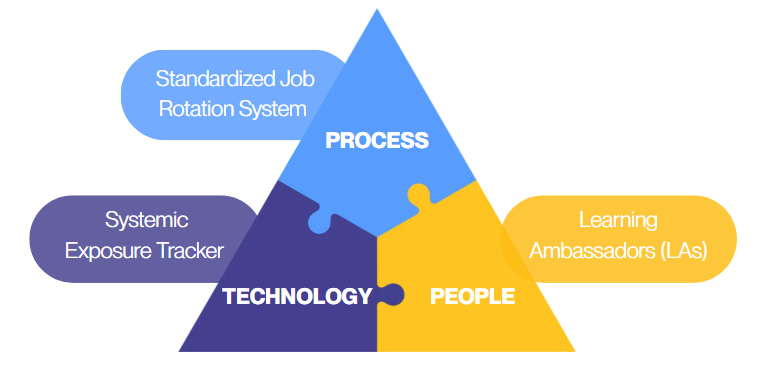

The intervention is primarily process-driven through standardized task rotation, supported by frontline enforcement mechanisms and lightweight tracking technology.

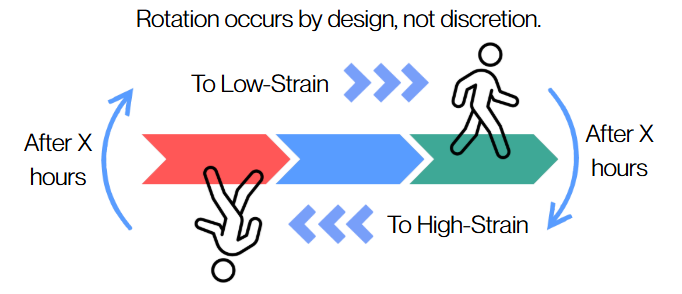

The proposed pilot introduces a standardized task rotation process for Tier 1 Associates within high-strain fulfillment functions. Associates rotate between high-strain and lower-strain tasks based on predefined exposure thresholds, while a lightweight tracking tool monitors cumulative task exposure and flags potential over-assignment patterns in real time.

The intervention targets two compounding failure points identified in the data: **sustained physical strain from prolonged high-intensity task assignment, and the discretionary burden placed on managers during peak operational windows.** By embedding rotation logic as an operational standard rather than a managerial judgement call, the pilot aims to improve workload sustainability, reduce perceptions of bias, and maintain productivity consistency where it is most at risk.

###**Implementation Scope**

| Component       | Pilot Scope                        |
| --------------- | ---------------------------------- |
| Target Segment  | Tier 1 Associates                  |
| Pilot Area      | Picking / Packing Fulfillment Zone |
| Pilot Duration  | 1–2 Weeks                          |
| Pilot Owner     | Learning Ambassador                |
| Support Role    | Area Manager                       |
| Monitoring Tool | Shared Exposure Tracking Scorecard |


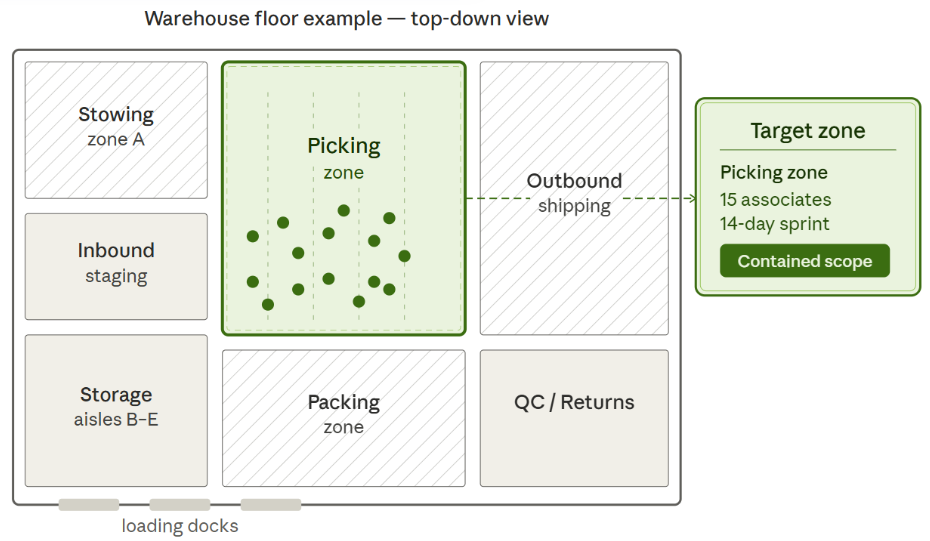

###**Success Metrics Scorecard**

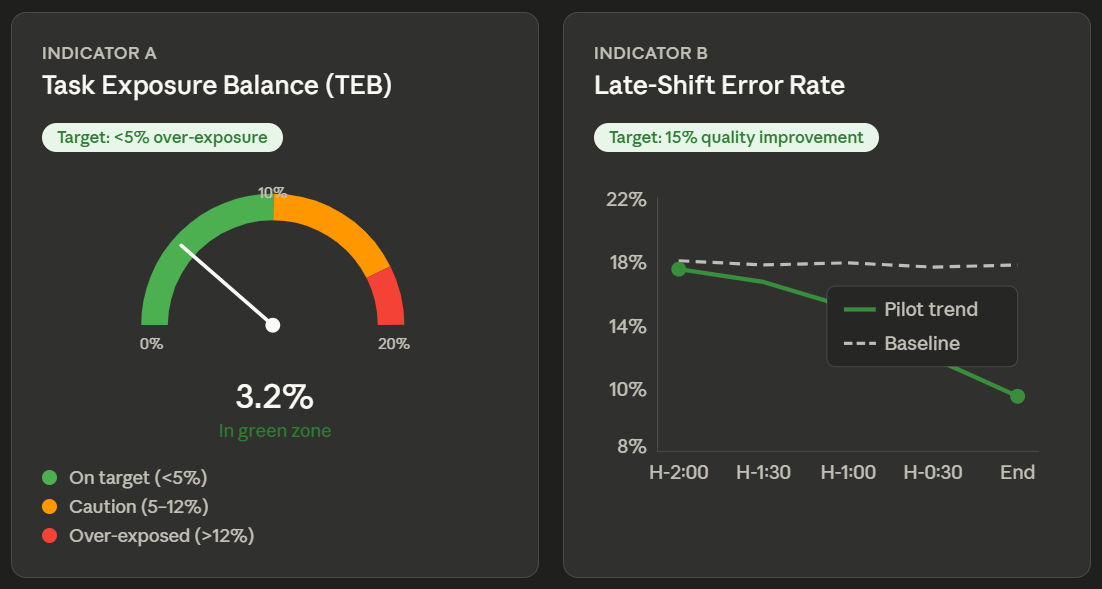

| Metric                | Purpose                                      |
| --------------------- | -------------------------------------------- |
| Task Exposure Balance | Tracks over-assignment to high-strain roles  |
| Late-Shift Error Rate | Measures fatigue-related performance decline |


The pilot focuses on operationally observable indicators that can be monitored in near-real time. Rather than relying solely on post-hoc attrition outcomes, the intervention emphasizes early strain visibility and sustainable workload balancing during active shift operations.

| Design Principle | Validation                                          |
| ---------------- | --------------------------------------------------- |
| Low-Cost         | Uses existing staff and lightweight tracking tools  |
| High-Impact      | Targets burnout-related operational strain directly |
| Measurable       | Uses real-time exposure and error metrics           |
| Team-Led         | Managed at frontline supervisory level              |


The intervention design was informed by existing ergonomic rotation practices used in high-throughput operational environments, including manufacturing and warehouse settings, where structured workload balancing has been associated with reduced strain-related risk and more sustainable frontline operations.